In [29]:
#!pip install yfinance

In [30]:
import yfinance as yf
import pandas as pd
from IPython.display import display, HTML

display(HTML("<style>.container { width:90% ! important; }</style>"))

import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [31]:
indices_df = pd.read_csv('../data/us_indices_data.csv')
indices_df.head()

,Ticker,Name,Category
0,^GSPC,S&P 500,US Equities
1,^DJI,Dow Jones,US Equities
2,^IXIC,Nasdaq Composite,US Equities
3,^RUT,Russell 2000,US Equities
4,^VIX,CBOE Volatility Index,US Equities


In [32]:
#cob_date = '2025-04-01'  # Change this to the desired date

cob_date = '2025-12-31'  # Change this to the desired date

#cob_date = datetime.today().strftime('%Y-%m-%d')
cob_date_dt = datetime.strptime(cob_date, '%Y-%m-%d')
year_end_date = (cob_date_dt).replace(day=1, month=1) - timedelta(days=1)

print(f"Calculating for COB date: {cob_date}")
print(f"Year end date derived from COB date: {year_end_date.strftime('%Y-%m-%d')}")

Calculating for COB date: 2025-12-31
Year end date derived from COB date: 2024-12-31


In [33]:
index_types_list = indices_df['Category'].unique().tolist()
index_ticker_map = {}

for index_type in index_types_list:
    tickers = indices_df[indices_df['Category'] == index_type]['Ticker'].tolist()
    index_ticker_map[index_type] = tickers
index_ticker_map

{'US Equities': ['^GSPC', '^DJI', '^IXIC', '^RUT', '^VIX'],
 'US Cyclic Sectors ': ['XLB', 'XLI', 'XLK', 'XLY', 'XLF', 'XLC'],
 'US Defensive Sectors': ['XLRE', 'XLP', 'XLE', 'XLV', 'XLU'],
 'Ex US Equities': ['^FTSE', '^FCHI', '^GDAXI', '^N225', '^NSEI', '^HSI'],
 'US Rates': ['^IRX', '^FVX', '^TNX', '^TYX'],
 'FX': ['EURUSD=X', 'JPY=X', 'GBPUSD=X', 'USDCNY=X'],
 'Commodity': ['CL=F', 'NG=F', 'GC=F', 'SI=F', 'HG=F'],
 'Crypto': ['BTC-USD', 'ETH-USD', 'SOL-USD', 'XRP-USD']}

In [34]:
ticker_names = indices_df.set_index('Ticker')['Name'].to_dict()
#ticker_names

In [35]:
# Function to fetch data
def fetch_data(tickers, start_dt, end_dt):
    df = yf.download(tickers, start=start_dt, end=end_dt)
    df = df['Close']
    return df

# Fetch data for all indices
#selected_timeframe = "Year to Date"  # Change this variable to adjust the timeframe
#period = timeframes[selected_timeframe]

dashboard_data = {}
for asset_class, tickers in index_ticker_map.items():
    dashboard_data[asset_class] = fetch_data(tickers, start_dt = f"{year_end_date.strftime('%Y-%m-%d')}", end_dt=cob_date)

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  4 of 4 completed


Asset Class: US Equities


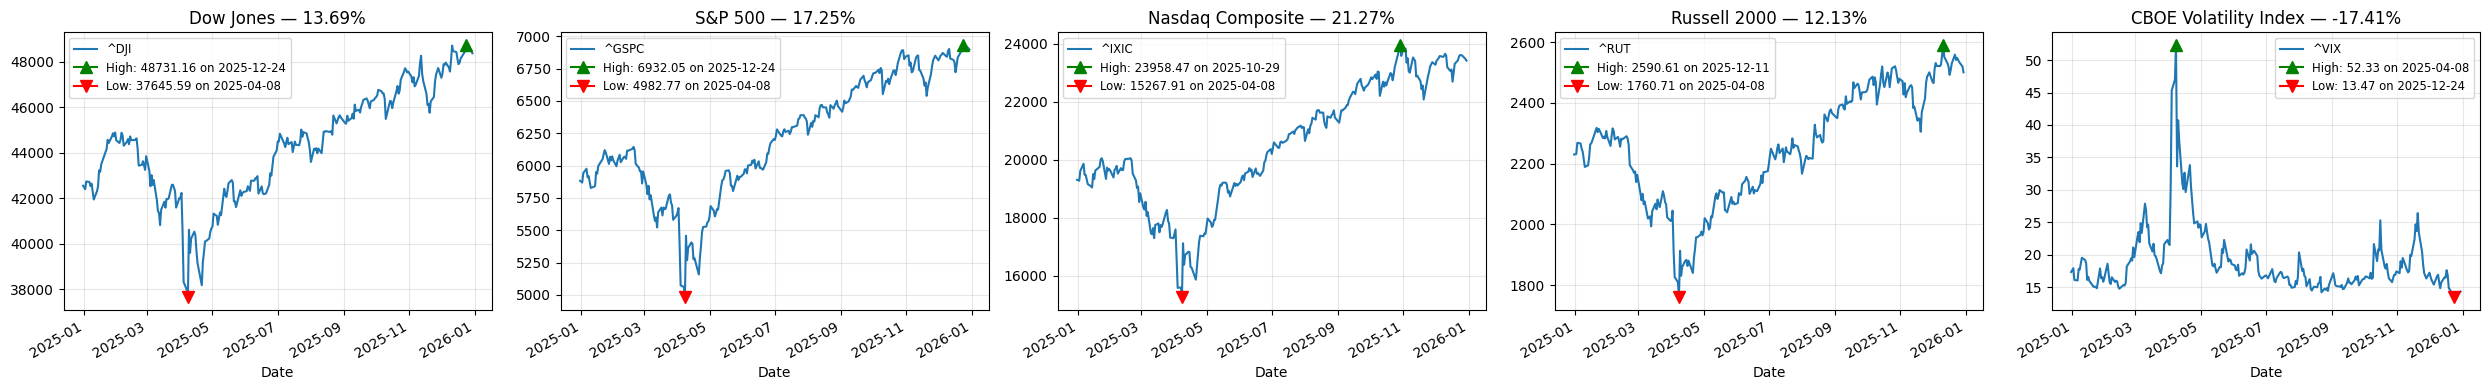

Asset Class: US Cyclic Sectors 


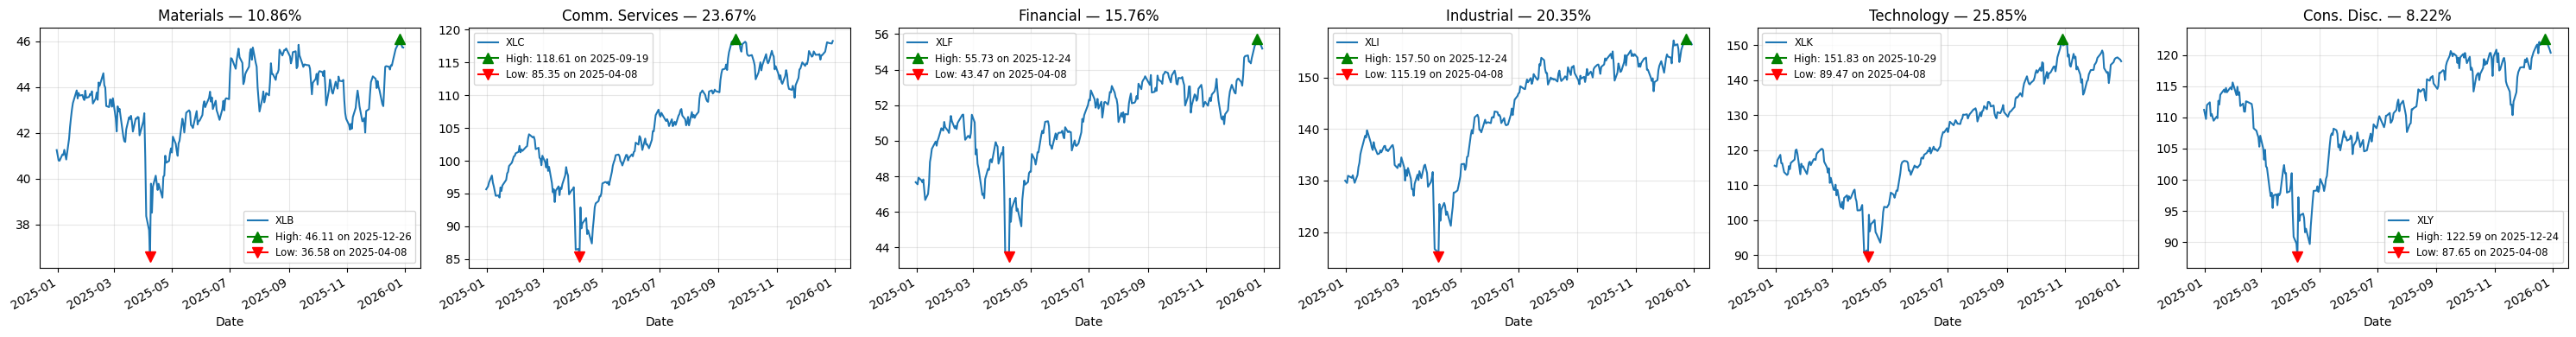

Asset Class: US Defensive Sectors


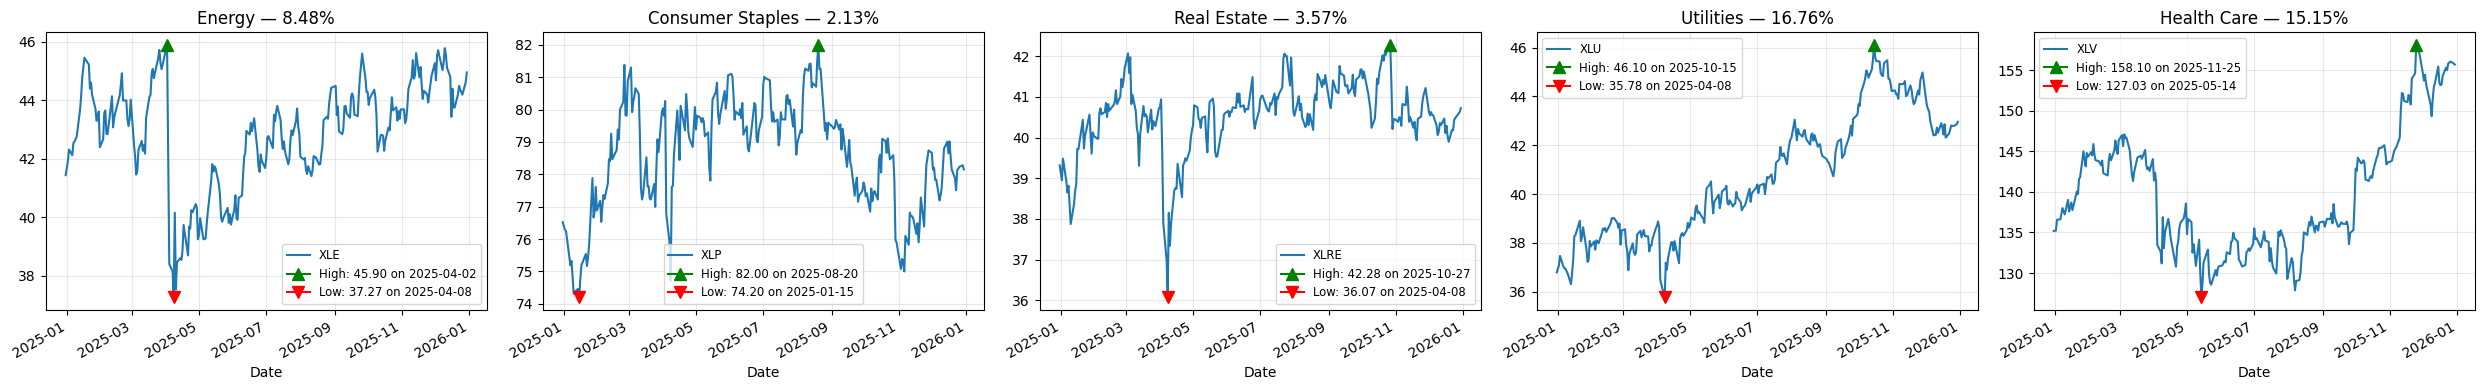

Asset Class: Ex US Equities


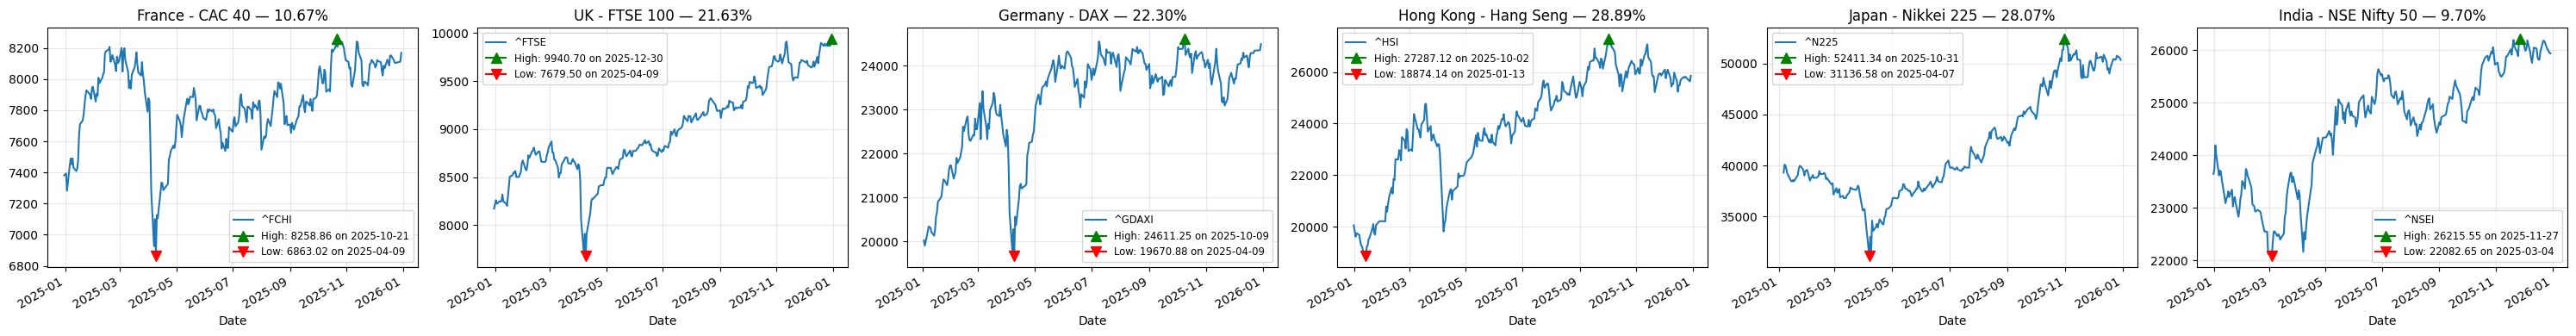

Asset Class: US Rates


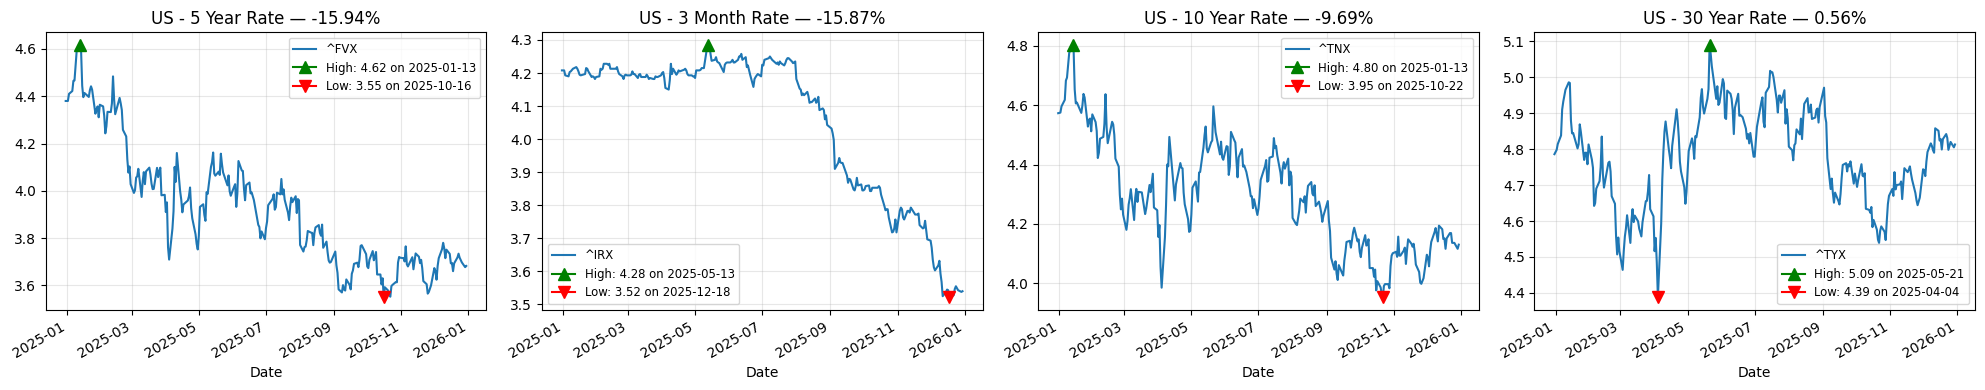

Asset Class: FX


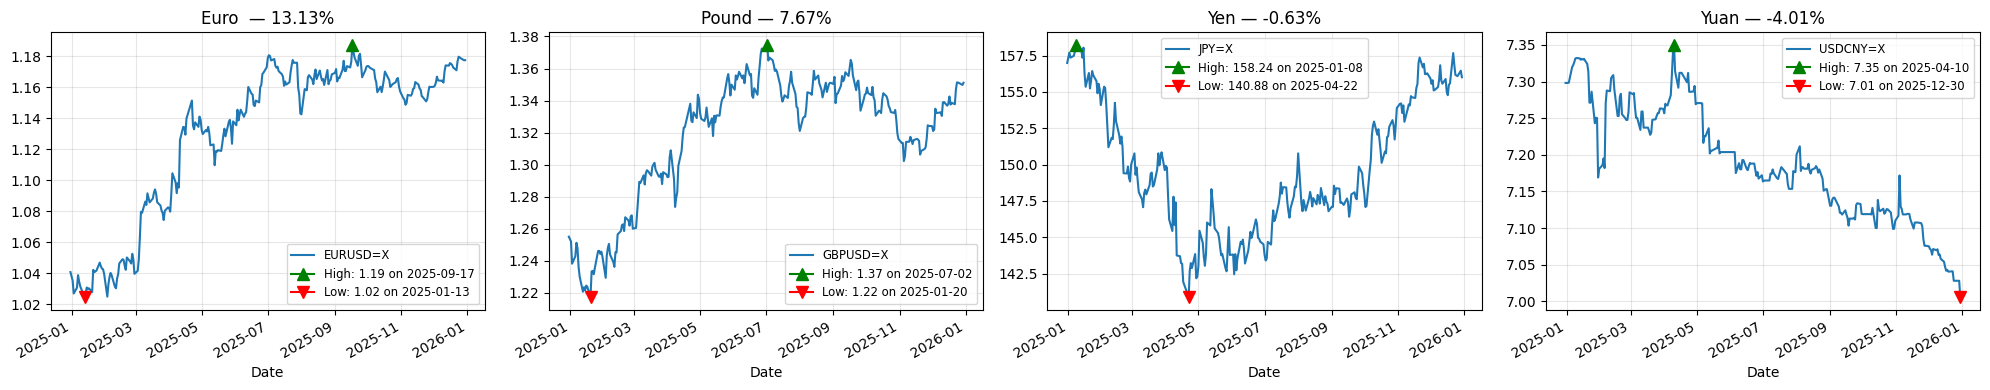

Asset Class: Commodity


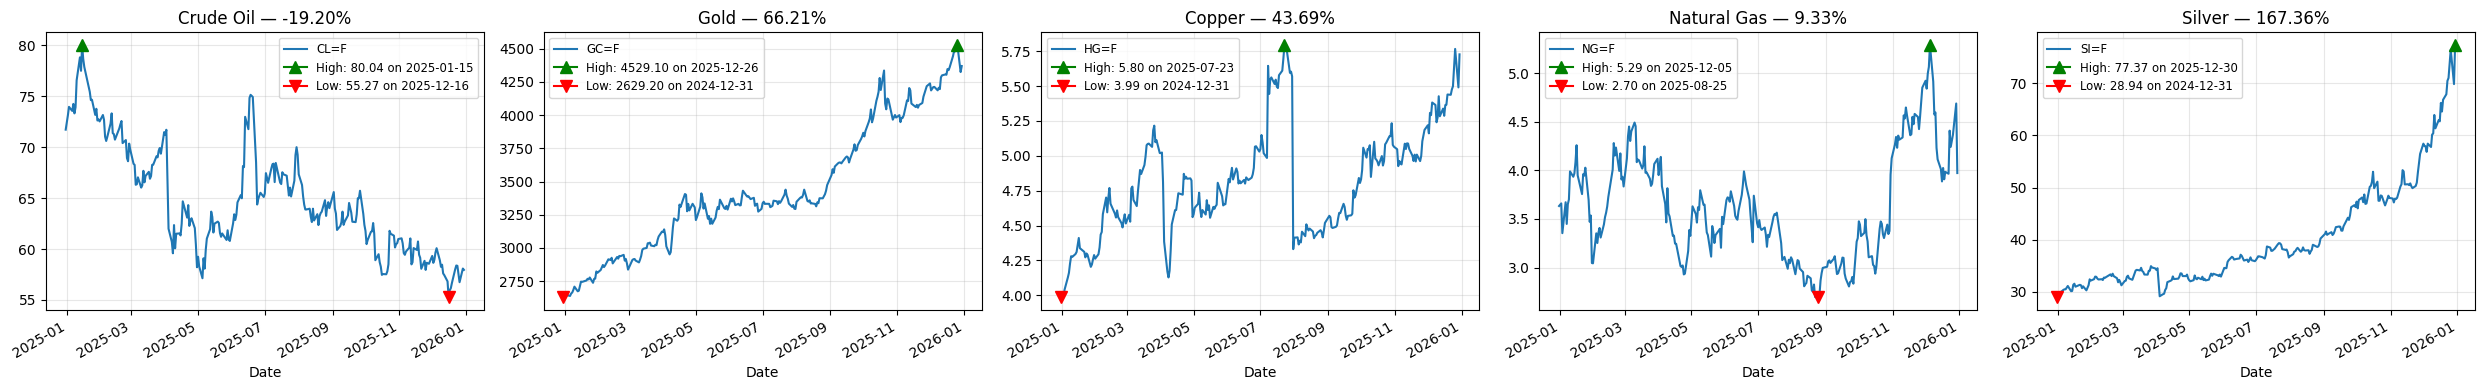

Asset Class: Crypto


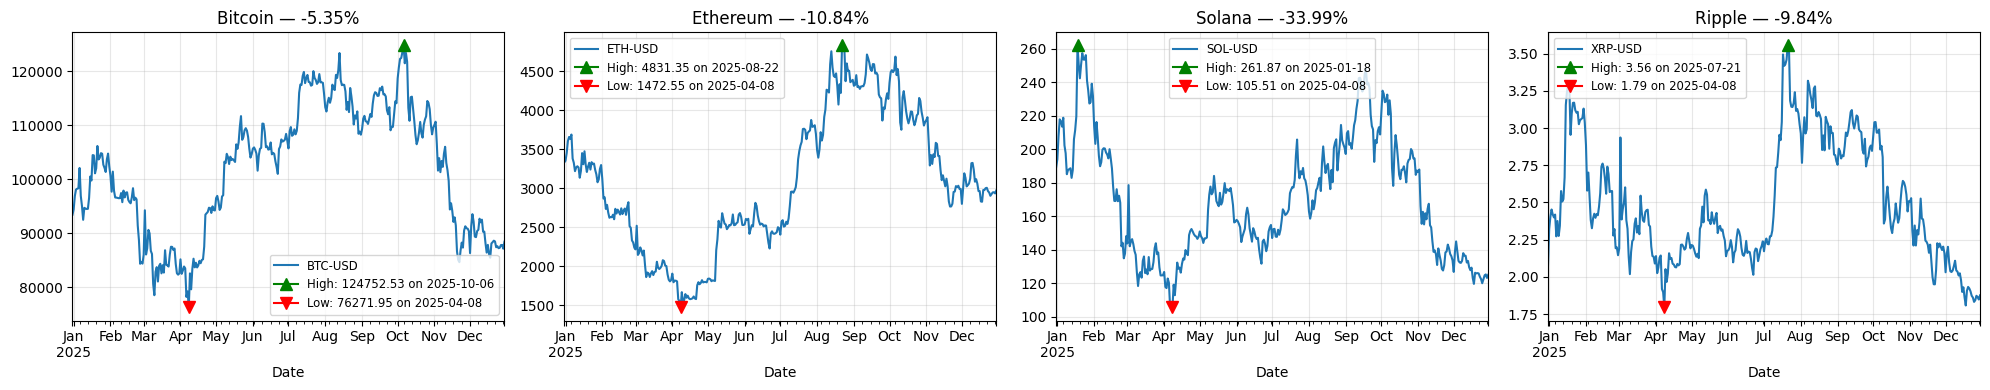

In [37]:
# Display data and charts
for asset_class, df in dashboard_data.items():
    print(f"Asset Class: {asset_class}")
    fig, axes = plt.subplots(ncols=len(df.columns), nrows=1, figsize=(5 * len(df.columns),4))

    # Normalize axes to a list when only one subplot exists
    axes_list = axes if hasattr(axes, '__len__') else [axes]

    for i, column in enumerate(df.columns):
        ax = axes_list[i]
        series = df[column].dropna()
        if series.empty:
            ax.set_title(ticker_names[column])
            continue

        # Ensure chronological order
        series = series.sort_index()

        # Compute percent return over the period (first available -> last available)
        try:
            start_val = series.iloc[0]
            end_val = series.iloc[-1]
            pct_return = (end_val / start_val - 1) * 100
        except Exception:
            pct_return = float('nan')

        # Plot series with percent return in title
        series.plot(ax=ax, title=f"{ticker_names[column]} — {pct_return:.2f}%", xlabel=None)

        # Find high and low points
        high_idx = series.idxmax()
        high_val = series.max()
        low_idx = series.idxmin()
        low_val = series.min()

        # Plot markers for high and low
        ax.plot(high_idx, high_val, marker='^', color='green', markersize=8, label=f"High: {high_val:.2f} on {pd.to_datetime(high_idx).strftime('%Y-%m-%d')}")
        ax.plot(low_idx, low_val, marker='v', color='red', markersize=8, label=f"Low: {low_val:.2f} on {pd.to_datetime(low_idx).strftime('%Y-%m-%d')}")

        # Add legend and grid
        ax.legend(fontsize='small')
        ax.grid(alpha=0.3)

    plt.tight_layout()  # Adjust subplot spacing
    plt.show()